In [1]:
import numpy  as np 
import matplotlib.pyplot as plt

In [2]:
# Given 
fs = 8000
fc = 1000
N = 21
M = (N-1)//2

In [3]:
n = np.arange(N)
print(n)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [4]:
# Normalized CutOff
wc = 2*np.pi*fc/fs
print(wc)

0.7853981633974483


In [5]:
# Ideal Impulse Response 
hd = 2 * fc/fs * np.sinc(2 * fc * (n-M)/fs)
print(hd)

[ 3.18309886e-02  2.50087866e-02 -9.74542958e-18 -3.21541541e-02
 -5.30516477e-02 -4.50158158e-02  9.74542958e-18  7.50263597e-02
  1.59154943e-01  2.25079079e-01  2.50000000e-01  2.25079079e-01
  1.59154943e-01  7.50263597e-02  9.74542958e-18 -4.50158158e-02
 -5.30516477e-02 -3.21541541e-02 -9.74542958e-18  2.50087866e-02
  3.18309886e-02]


In [6]:
# Hamming Window 
w = .54  - (.46*np.cos(2*np.pi*n/(N-1)))

In [7]:
# Final FIR Filter 
h = hd * w

In [8]:
H = np.zeros(N,dtype=complex)

In [9]:
for k in range(N):
    for i in range (N) :
        H[k] += h[i] * np.exp(-1j * 2 * np.pi * k * i/N)

In [10]:
magnitude = np.abs(H)
phase = np.angle(H)

Text(0.5, 1.0, 'Phase')

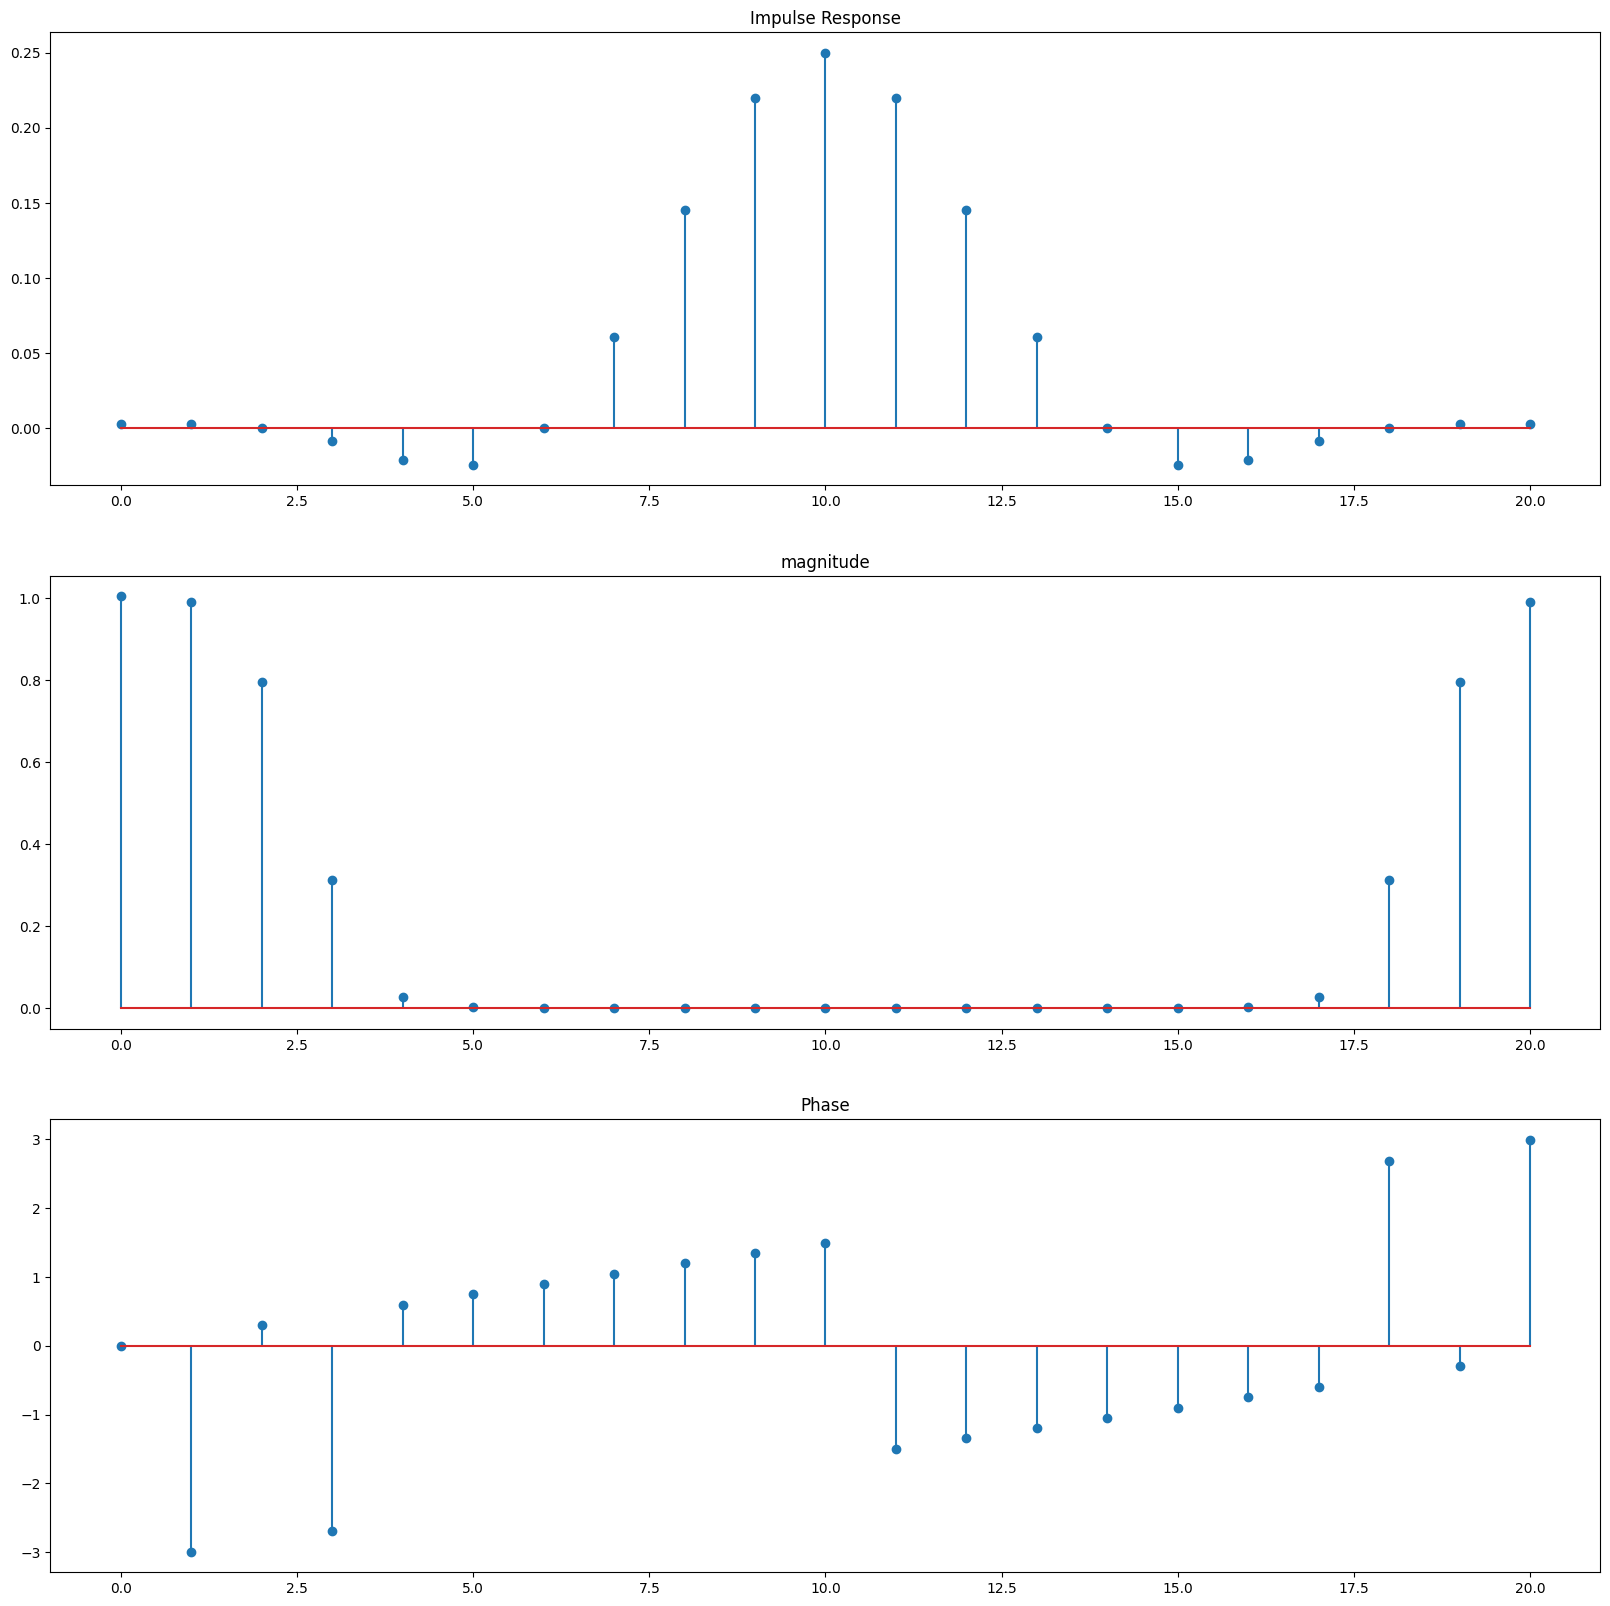

In [11]:
plt.figure(figsize=(20,20))
plt.subplot(3,1,1)
plt.stem(n,h)
plt.title("Impulse Response")
plt.subplot(3,1,2)
plt.stem(magnitude)
plt.title("magnitude")
plt.subplot(3,1,3)
plt.stem(phase)
plt.title("Phase")
